# 🥛 Milk Adulteration Detection — Complete End-to-End ML Pipeline
**Dataset:** Synthetic Indian Dairy Brands Dataset (2,500 samples · 25 brands · 128 features)  
**Tasks:** Binary Classification · Multi-class Adulterant ID · Anomaly Detection  
**Standards:** FSSAI / IS:1479 / ISO 9622

## 📦 Step 0 — Install & Import

In [5]:
# Install if needed
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils import resample

print('All libraries loaded ✅')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

All libraries loaded ✅


## 📂 Step 1 — Load & Clean Data

In [6]:
# ── Load dataset ──
# Auto-detect path: works on Kaggle AND locally
import os, glob

matches = glob.glob('/kaggle/input/**/milk_combined_full_dataset.csv', recursive=True)
if not matches:
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files: print(os.path.join(root, f))
    raise FileNotFoundError("File not found — see list above")

CSV_PATH = matches[0]
print(f"Found at: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

# Remove __META_ reference columns (not features)
orig_cols = [c for c in df.columns if '__META_' not in c]
df = df[orig_cols].copy()

# Fix Adulterant_Detected: NaN = pure milk
df['Adulterant_Detected'] = df['Adulterant_Detected'].fillna('None')

# Fix binary spot test columns: NaN = test not done = negative (0)
BINARY_COLS = [
    'Starch_Test','Detergent_Test','Formalin_Test','H2O2_Test','SMP_Booster_Flag',
    'Peroxidase_Activity','Iodine_Test_Starch','DMAB_Test_Urea','Urease_Strip_Urea',
    'Methylene_Blue_Detergent','FeSO4_H2SO4_Test_Formalin','Schiff_Test_Formalin',
    'Vanadate_Test_H2O2','TiO2_Strip_H2O2','Rosalic_Acid_Test_Alkali','CTAB_Test_NaHCO3',
    'Baudouin_Test_VegOil','Halphen_Test_CottonseedOil','Benedict_Test_Glucose',
    'GOD_Strip_Glucose','Nessler_Test_Ammonium','Turmeric_Paper_BoricAcid',
    'FeCl3_Test_SalicylicAcid','AgNO3_Test_Salt'
]
for c in BINARY_COLS:
    if c in df.columns:
        df[c] = df[c].fillna(0).astype(int)

print(f'Dataset shape : {df.shape}')
print(f'Adulterated   : {df["Is_Adulterated"].sum()} ({df["Is_Adulterated"].mean()*100:.1f}%)')
print(f'Pure samples  : {(df["Is_Adulterated"]==0).sum()}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(3)

Found at: /kaggle/input/datasets/ommadav/indian-milk-adulteration-detection-dataset/milk_combined_full_dataset.csv
Dataset shape : (2500, 128)
Adulterated   : 124 (5.0%)
Pure samples  : 2376
Missing values: 0


,Sample_ID,Company_Name,Brand_Name,Organization_Type,State,Market_Tier,Market_Segment,Collection_Date,Season,Collection_Point,...,ENose_Sensor_S03,ENose_Sensor_S04,ENose_Sensor_S05,ENose_Sensor_S06,ENose_Sensor_S07,ENose_Sensor_S08,ENose_Sensor_S09,ENose_Sensor_S10,Adulteration_Index_0_1,FSSAI_Chemical_Score
0,MS02052,Akshayakalpa Organic,Akshayakalpa,Private,Karnataka,Premium,South India,2022-10-14,Monsoon (Jun-Sep),District Chilling Center,...,0.1956,0.2407,0.2828,0.2874,0.2606,0.2607,0.2932,0.4143,0.0,100.00
1,MS00315,Heritage Foods Ltd.,Heritage,Private,Telangana,Premium,South India,2022-12-14,Monsoon (Jun-Sep),Processing Plant,...,0.1677,0.1944,0.2561,0.3242,0.2270,0.2281,0.2090,0.2387,0.0,100.00
2,MS01885,Chitale Bandhu Mithaiwale (B.G. Chitale),Chitale,Private,Maharashtra,Premium,West India,2022-04-02,Summer (Mar-May),Farm Gate,...,0.2058,0.2317,0.3022,0.2965,0.2434,0.2851,0.3781,0.4377,0.0,97.78


## 🔍 Step 2 — Exploratory Data Analysis (EDA)

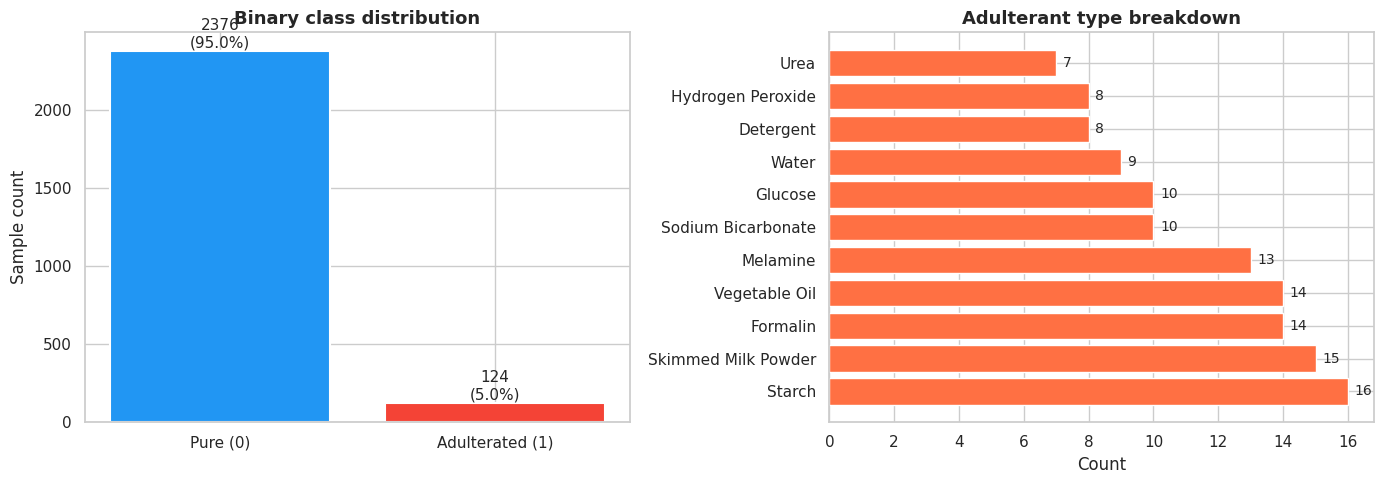

⚠️  Class imbalance: 95% pure vs 5% adulterated — must use class_weight or SMOTE


In [7]:
# ── 2.1 Class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
counts = df['Is_Adulterated'].value_counts()
axes[0].bar(['Pure (0)', 'Adulterated (1)'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Binary class distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Adulterant breakdown
adult_counts = df[df['Is_Adulterated']==1]['Adulterant_Detected'].value_counts()
axes[1].barh(adult_counts.index, adult_counts.values, color='#FF7043')
axes[1].set_title('Adulterant type breakdown', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(adult_counts.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Class imbalance: 95% pure vs 5% adulterated — must use class_weight or SMOTE')

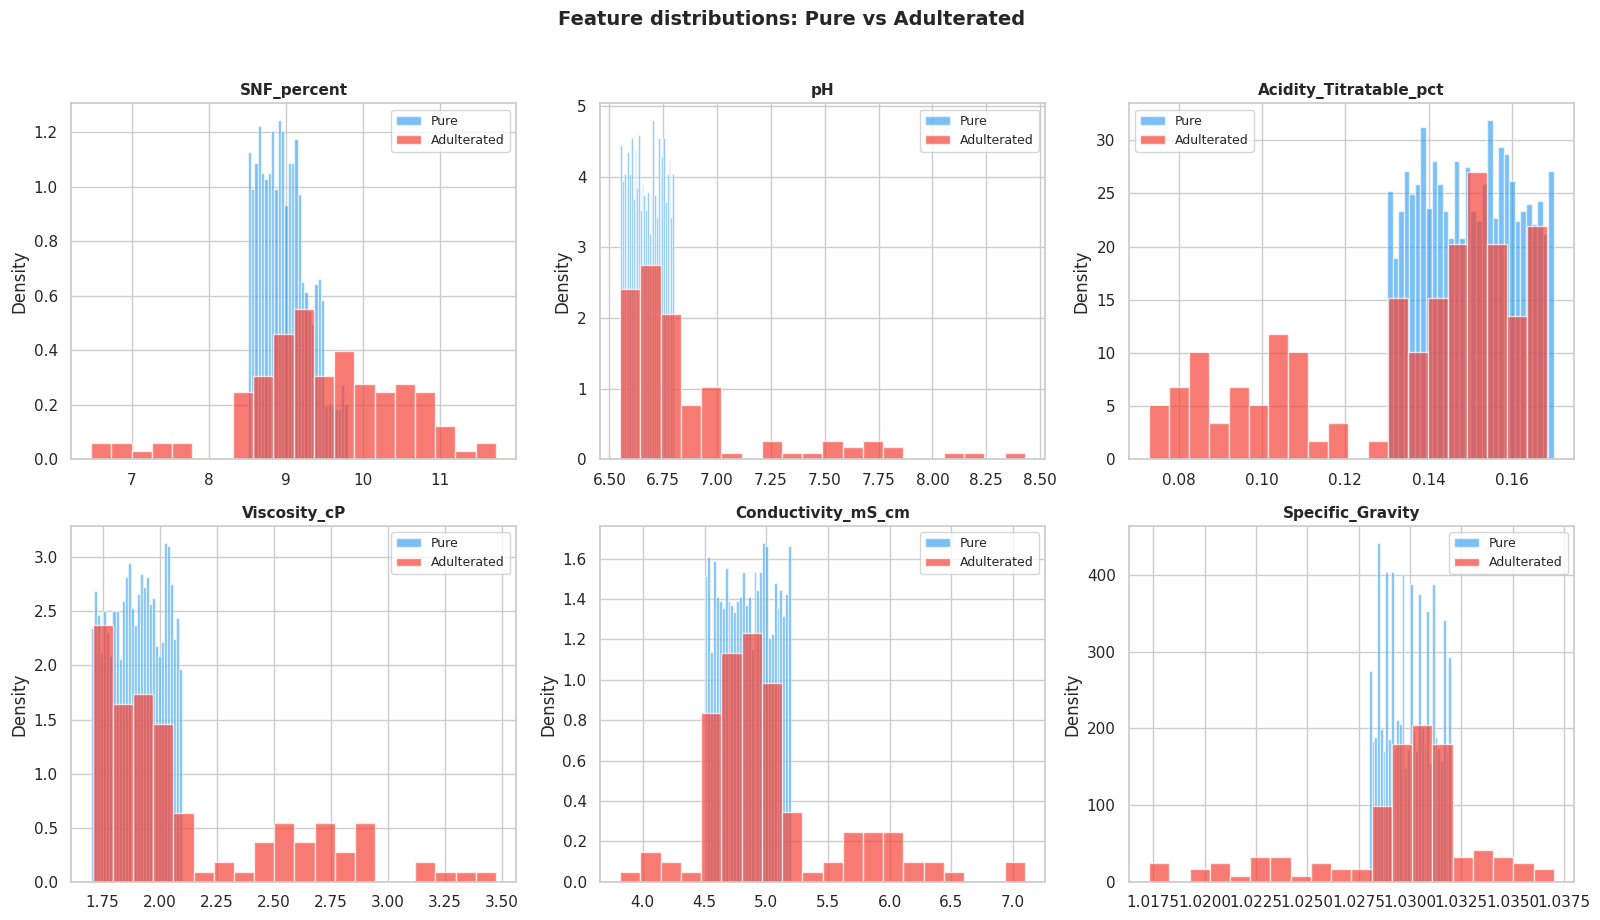

In [8]:
# ── 2.2 Key feature distributions by label ──
KEY_FEATURES = ['SNF_percent','pH','Acidity_Titratable_pct','Viscosity_cP',
                'Conductivity_mS_cm','Specific_Gravity']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    pure = df[df['Is_Adulterated']==0][feat].dropna()
    adul = df[df['Is_Adulterated']==1][feat].dropna()
    axes[i].hist(pure, bins=30, alpha=0.6, label='Pure', color='#2196F3', density=True)
    axes[i].hist(adul, bins=20, alpha=0.7, label='Adulterated', color='#F44336', density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature distributions: Pure vs Adulterated', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

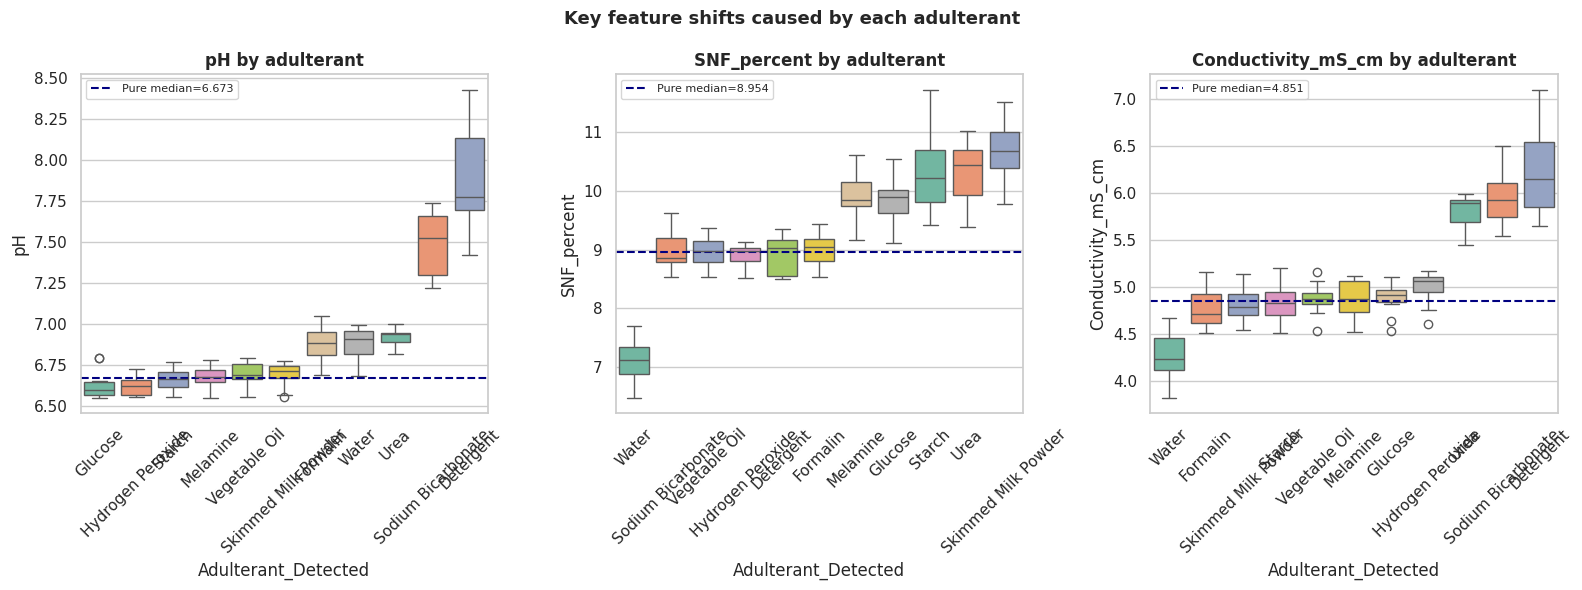

In [9]:
# ── 2.3 Boxplots by adulterant type ──
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
plot_feats = ['pH', 'SNF_percent', 'Conductivity_mS_cm']

for ax, feat in zip(axes, plot_feats):
    data = df[df['Adulterant_Detected']!='None']
    order = data.groupby('Adulterant_Detected')[feat].median().sort_values().index
    sns.boxplot(data=data, x='Adulterant_Detected', y=feat,
                order=order, ax=ax, palette='Set2')
    # Add pure milk reference line
    pure_med = df[df['Adulterant_Detected']=='None'][feat].median()
    ax.axhline(pure_med, color='navy', linestyle='--', linewidth=1.5, label=f'Pure median={pure_med:.3f}')
    ax.set_title(f'{feat} by adulterant', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Key feature shifts caused by each adulterant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_boxplots_by_adulterant.png', dpi=150, bbox_inches='tight')
plt.show()

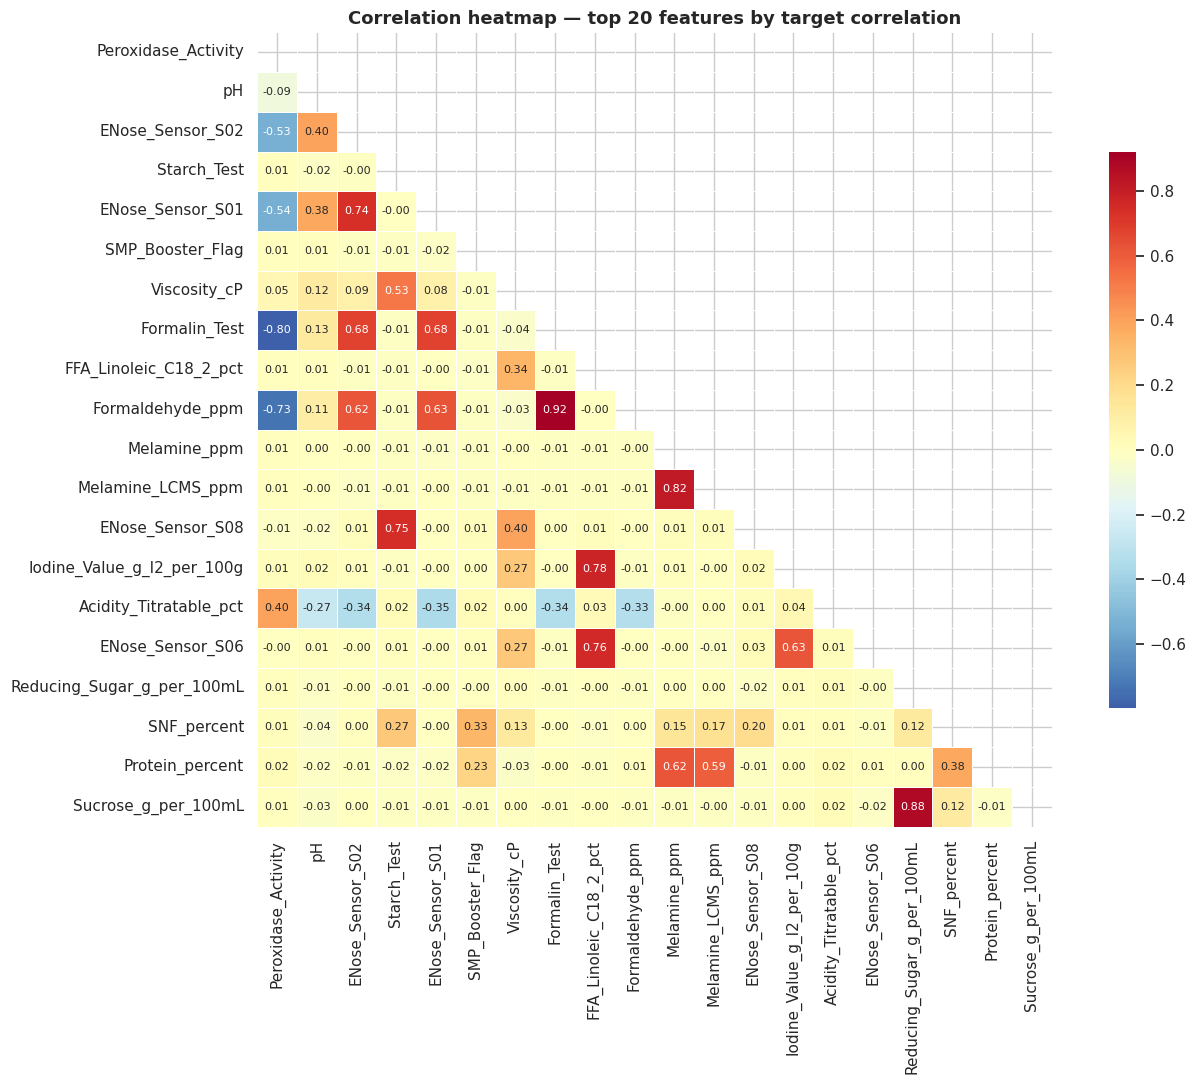

In [10]:
# ── 2.4 Correlation heatmap (top 20 numeric features) ──
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in
                ['Is_Adulterated','Adulteration_Index_0_1','FSSAI_Chemical_Score','Quality_Score_0_100']]

# Pick top 20 by correlation with target
corr_with_target = df[numeric_cols].corrwith(df['Is_Adulterated']).abs().sort_values(ascending=False)
top20 = corr_with_target.head(20).index.tolist()

plt.figure(figsize=(14, 11))
corr_matrix = df[top20].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8})
plt.title('Correlation heatmap — top 20 features by target correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

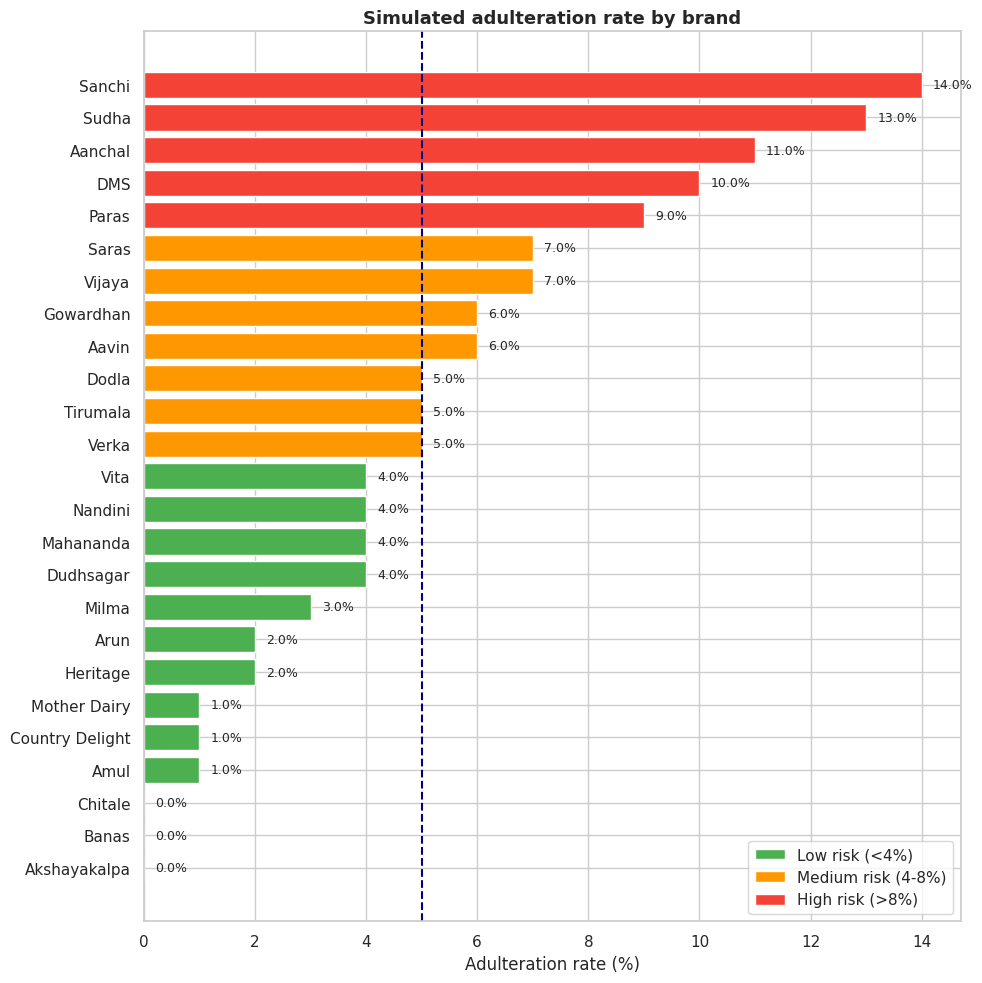

In [11]:
# ── 2.5 Brand-wise adulteration rate ──
brand_stats = df.groupby('Brand_Name').agg(
    adulteration_rate=('Is_Adulterated', 'mean'),
    total_samples=('Is_Adulterated', 'count')
).sort_values('adulteration_rate', ascending=True)

brand_stats['adulteration_pct'] = brand_stats['adulteration_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#F44336' if v > 8 else '#FF9800' if v > 4 else '#4CAF50'
          for v in brand_stats['adulteration_pct']]
bars = ax.barh(brand_stats.index, brand_stats['adulteration_pct'], color=colors, edgecolor='white')
ax.axvline(5, color='navy', linestyle='--', linewidth=1.5, label='Dataset avg (5%)')
for bar, v in zip(bars, brand_stats['adulteration_pct']):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Adulteration rate (%)', fontsize=12)
ax.set_title('Simulated adulteration rate by brand', fontsize=13, fontweight='bold')
ax.legend()
# Color legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Low risk (<4%)'),
                   Patch(facecolor='#FF9800', label='Medium risk (4-8%)'),
                   Patch(facecolor='#F44336', label='High risk (>8%)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('plot_05_brand_adulteration_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Step 3 — Feature Engineering & Selection

In [12]:
# ── Columns to exclude from features ──
EXCLUDE = [
    'Sample_ID','Company_Name','Brand_Name','Organization_Type','State',
    'Market_Tier','Market_Segment','Collection_Date','Season','Collection_Point',
    'Milk_Type','Adulterant_Detected','Is_Adulterated','FSSAI_Compliance',
    # Leakage columns (derived from label):
    'Adulteration_Index_0_1','FSSAI_Chemical_Score','Quality_Score_0_100',
    # Text result columns (redundant with their binary counterparts):
    'Iodine_Test_Result','DMAB_Test_Color','Urease_Strip_Result','Methylene_Blue_Result',
    'FeSO4_H2SO4_Result','Schiff_Test_Color','Vanadate_Test_Result','Rosalic_Acid_Color',
    'CTAB_Result','Baudouin_Test_Color','Benedict_Test_Color','Nessler_Test_Result',
    'Turmeric_Paper_Color','FeCl3_Test_Color','AgNO3_Test_Result',
    'ALP_Pasteurization_Status','Peroxidase_Test_Result'
]

X_full = df.drop(columns=[c for c in EXCLUDE if c in df.columns])
X_full = X_full.select_dtypes(include=[np.number]).fillna(0)
y      = df['Is_Adulterated']

print(f'Total raw features: {X_full.shape[1]}')

# ── SelectKBest: top 40 features by ANOVA F-score ──
selector = SelectKBest(f_classif, k=40)
selector.fit(X_full, y)
selected = X_full.columns[selector.get_support()].tolist()
X = X_full[selected]

print(f'Selected features : {len(selected)}')
print('\nTop selected features by F-score:')
scores = pd.Series(selector.scores_[selector.get_support()], index=selected)
print(scores.sort_values(ascending=False).head(10).round(2).to_string())

# Optional: add derived features
X = X.copy()
X['Fat_SNF_ratio']    = df['Fat_percent'] / (df['SNF_percent'] + 1e-6)
X['Urea_pH_product']  = df['Urea_mg_per_100mL'] * df['pH']
X['ENose_mean']       = df[[f'ENose_Sensor_S0{i}' for i in range(1,10)]].mean(axis=1)

print(f'\nFinal feature count with derived: {X.shape[1]}')

Total raw features: 94
Selected features : 40

Top selected features by F-score:
Peroxidase_Activity       512.06
pH                        368.94
ENose_Sensor_S02          358.08
Starch_Test               351.72
ENose_Sensor_S01          327.52
SMP_Booster_Flag          326.71
Viscosity_cP              304.64
Formalin_Test             302.16
FFA_Linoleic_C18_2_pct    270.92
Formaldehyde_ppm          251.28

Final feature count with derived: 43


## ⚖️ Step 4 — Train/Test Split & Handle Class Imbalance

In [13]:
# ── Split (stratified to preserve 5% adulteration ratio) ──
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Before balancing:')
print(f'  Train: {y_train_raw.value_counts().to_dict()}')
print(f'  Test:  {y_test.value_counts().to_dict()}')

# ── Oversample minority class (train only!) ──
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)
majority  = df_train[df_train['Is_Adulterated'] == 0]
minority  = df_train[df_train['Is_Adulterated'] == 1]
minority_upsampled = resample(minority, replace=True,
                               n_samples=len(majority), random_state=42)
df_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

X_train = df_balanced[X.columns]
y_train = df_balanced['Is_Adulterated']

print('\nAfter balancing (train only):')
print(f'  Train: {y_train.value_counts().to_dict()}')
print(f'  Test (unchanged): {y_test.value_counts().to_dict()}')
print('\n✅ Test set kept at original distribution — fair evaluation')

Before balancing:
  Train: {0: 1901, 1: 99}
  Test:  {0: 475, 1: 25}

After balancing (train only):
  Train: {1: 1901, 0: 1901}
  Test (unchanged): {0: 475, 1: 25}

✅ Test set kept at original distribution — fair evaluation


## 🤖 Step 5 — Train Multiple Models

In [14]:
# ── Define pipelines ──
pipelines = {
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            max_depth=15, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(
            n_estimators=150, max_depth=5,
            learning_rate=0.1, random_state=42
        ))
    ]),
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(
            C=1.0, class_weight='balanced',
            max_iter=1000, random_state=42
        ))
    ]),
    'SVM (RBF)': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=1.0, probability=True,
            class_weight='balanced', random_state=42
        ))
    ]),
    'KNN (k=5)': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ])
}

# ── Train all ──
print('Training models...')
results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test_raw)
    y_prob = pipe.predict_proba(X_test_raw)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'ROC_AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
    }
    print(f'  ✅ {name} done')

results_df = pd.DataFrame(results).T
print('\n=== Model Comparison ===')
print(results_df.to_string())

Training models...
  ✅ Random Forest done
  ✅ Gradient Boosting done
  ✅ Logistic Regression done
  ✅ SVM (RBF) done
  ✅ KNN (k=5) done

=== Model Comparison ===
                     Accuracy  ROC_AUC      F1  Precision  Recall
Random Forest           100.0   1.0000  1.0000        1.0    1.00
Gradient Boosting        99.6   0.9998  0.9583        1.0    0.92
Logistic Regression     100.0   1.0000  1.0000        1.0    1.00
SVM (RBF)               100.0   1.0000  1.0000        1.0    1.00
KNN (k=5)               100.0   1.0000  1.0000        1.0    1.00


## 📊 Step 6 — Evaluate & Visualise Results

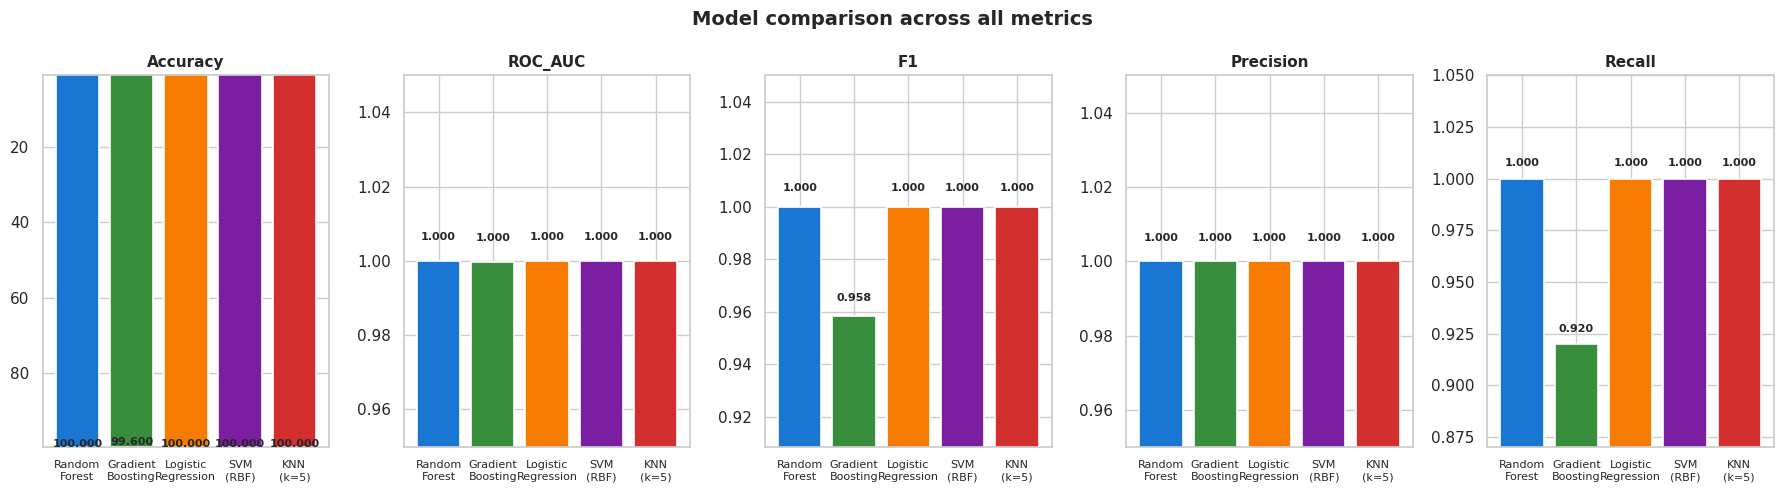

In [15]:
# ── 6.1 Model comparison bar chart ──
metrics = ['Accuracy', 'ROC_AUC', 'F1', 'Precision', 'Recall']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#D32F2F']

for i, metric in enumerate(metrics):
    vals  = results_df[metric].values
    names = results_df.index.tolist()
    bars  = axes[i].bar(range(len(names)), vals, color=colors, edgecolor='white', linewidth=1.2)
    axes[i].set_xticks(range(len(names)))
    axes[i].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
    axes[i].set_title(metric, fontweight='bold', fontsize=11)
    ymin = max(0, min(vals) - 0.05)
    axes[i].set_ylim(ymin, 1.05)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model comparison across all metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

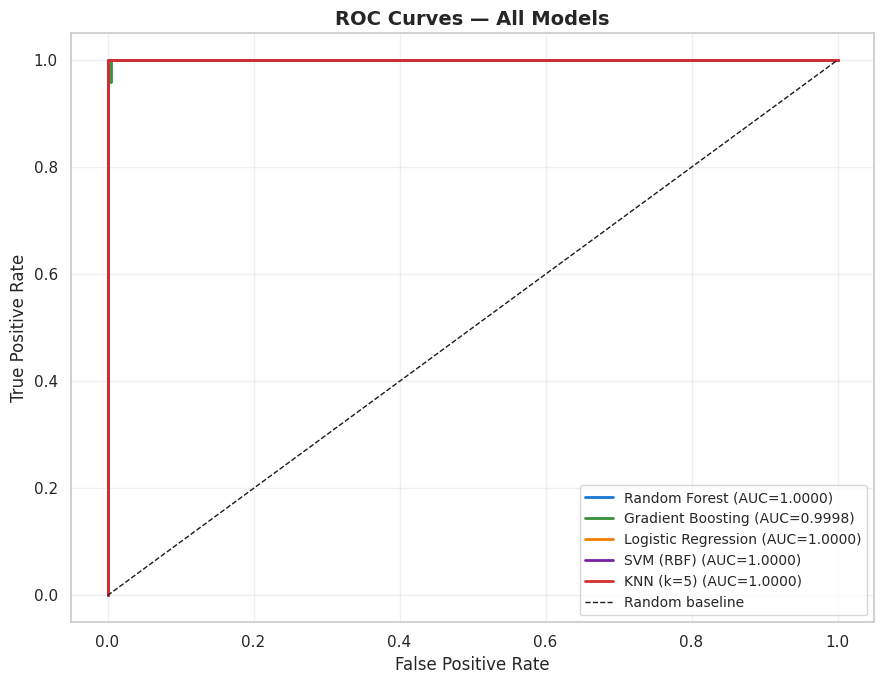

In [16]:
# ── 6.2 ROC curves for all models ──
plt.figure(figsize=(9, 7))
line_colors = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#D32F2F']

for (name, pipe), color in zip(pipelines.items(), line_colors):
    y_prob = pipe.predict_proba(X_test_raw)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

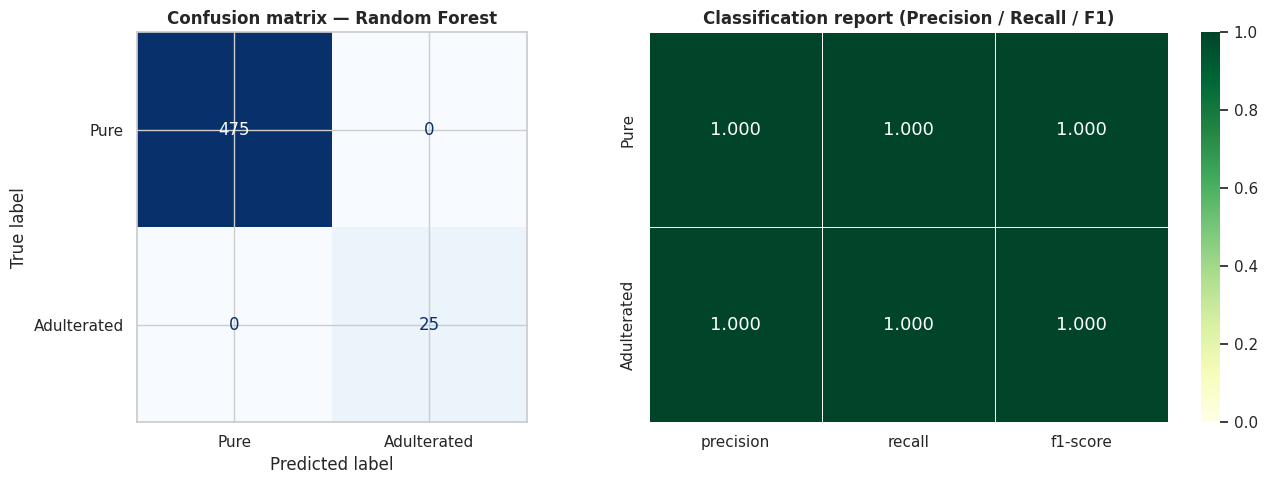

TN=475  FP=0  FN=0  TP=25

✅ False Negatives (missed adulterations): 0
⚠️  False Positives (false alarms): 0


In [17]:
# ── 6.3 Confusion matrix for best model (Random Forest) ──
best_pipe = pipelines['Random Forest']
y_pred_best = best_pipe.predict(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Pure', 'Adulterated'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix — Random Forest', fontweight='bold', fontsize=12)

# Classification report as heatmap
report = classification_report(y_test, y_pred_best,
                                 target_names=['Pure','Adulterated'],
                                 output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.iloc[:2, :3]
sns.heatmap(report_df.astype(float), annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1, annot_kws={'size': 13})
axes[1].set_title('Classification report (Precision / Recall / F1)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('plot_08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'\n✅ False Negatives (missed adulterations): {fn}')
print(f'⚠️  False Positives (false alarms): {fp}')

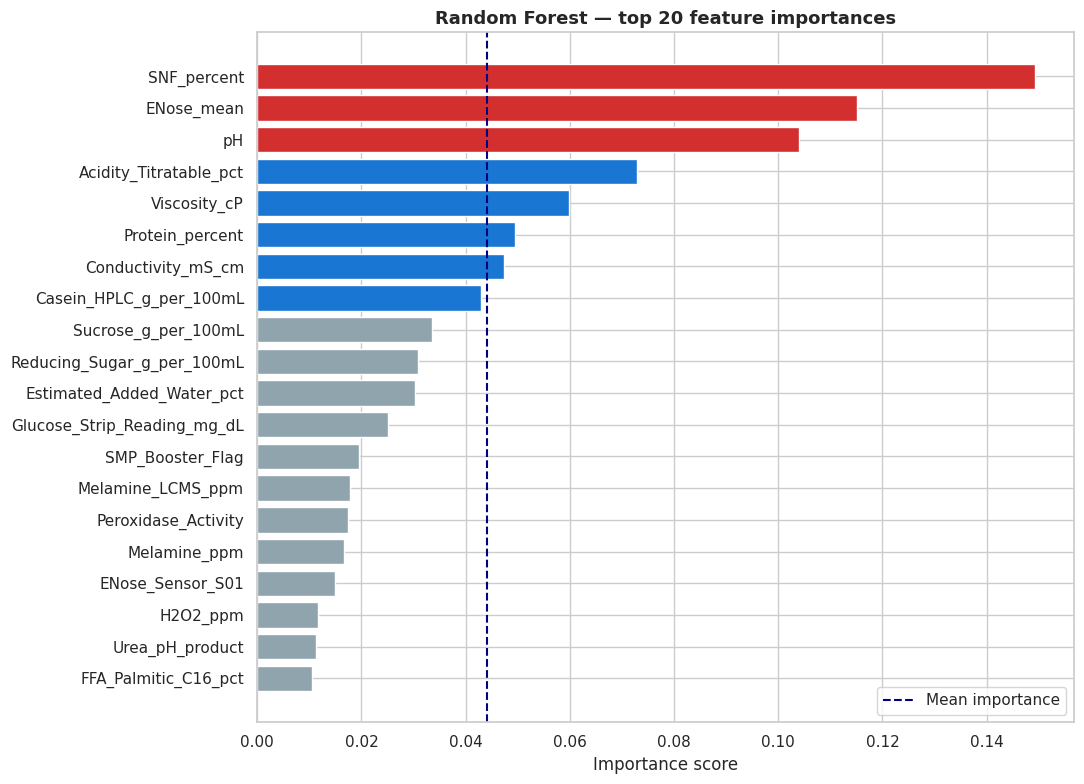

Top 5 most discriminative features:
  SNF_percent                         0.1493
  ENose_mean                          0.1152
  pH                                  0.1041
  Acidity_Titratable_pct              0.0728
  Viscosity_cP                        0.0598


In [18]:
# ── 6.4 Feature importance ──
rf_clf = best_pipe['clf']
feat_imp = pd.Series(rf_clf.feature_importances_,
                      index=X_train.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(11, 8))
colors_fi = ['#D32F2F' if v > 0.08 else '#1976D2' if v > 0.04 else '#90A4AE'
              for v in feat_imp.values]
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
         color=colors_fi[::-1], edgecolor='white')
plt.xlabel('Importance score', fontsize=12)
plt.title('Random Forest — top 20 feature importances', fontsize=13, fontweight='bold')
plt.axvline(feat_imp.mean(), color='navy', linestyle='--', linewidth=1.5, label='Mean importance')
plt.legend()
plt.tight_layout()
plt.savefig('plot_09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most discriminative features:')
for feat, score in feat_imp.head(5).items():
    print(f'  {feat:<35s} {score:.4f}')

## 🔄 Step 7 — Cross Validation

Running 5-fold cross validation...
  Random Forest           AUC=1.0000±0.0000  F1=0.9745±0.0250
  Gradient Boosting       AUC=1.0000±0.0000  F1=0.9835±0.0083
  Logistic Regression     AUC=1.0000±0.0000  F1=1.0000±0.0000


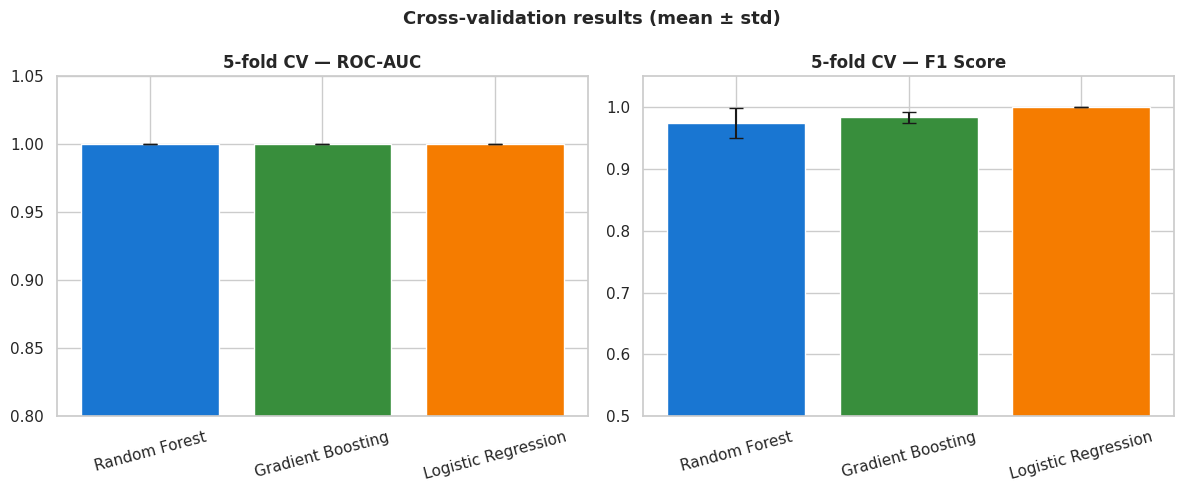

In [19]:
# ── 5-fold stratified cross validation on full dataset ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold cross validation...')
for name, pipe in list(pipelines.items())[:3]:  # top 3 models
    scores_auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    scores_f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
    cv_results[name] = {
        'AUC_mean': scores_auc.mean(), 'AUC_std': scores_auc.std(),
        'F1_mean':  scores_f1.mean(),  'F1_std':  scores_f1.std()
    }
    print(f'  {name:22s}  AUC={scores_auc.mean():.4f}±{scores_auc.std():.4f}  '
          f'F1={scores_f1.mean():.4f}±{scores_f1.std():.4f}')

# Visualise CV
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models_cv  = list(cv_results.keys())
auc_means  = [cv_results[m]['AUC_mean'] for m in models_cv]
auc_stds   = [cv_results[m]['AUC_std']  for m in models_cv]
f1_means   = [cv_results[m]['F1_mean']  for m in models_cv]
f1_stds    = [cv_results[m]['F1_std']   for m in models_cv]

x = np.arange(len(models_cv))
axes[0].bar(x, auc_means, yerr=auc_stds, capsize=5,
            color=['#1976D2','#388E3C','#F57C00'], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(models_cv, rotation=15)
axes[0].set_title('5-fold CV — ROC-AUC', fontweight='bold')
axes[0].set_ylim(0.8, 1.05)

axes[1].bar(x, f1_means, yerr=f1_stds, capsize=5,
            color=['#1976D2','#388E3C','#F57C00'], edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(models_cv, rotation=15)
axes[1].set_title('5-fold CV — F1 Score', fontweight='bold')
axes[1].set_ylim(0.5, 1.05)

plt.suptitle('Cross-validation results (mean ± std)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 🚨 Step 8 — Anomaly Detection (Unsupervised)

Isolation Forest Results:
  Accuracy : 93.7%
  F1 Score : 0.5228
  Recall   : 0.6935  (catches 69.4% of adulterations without any labels)

Top 10 most anomalous samples:
     Sample_ID Brand_Name Adulterant_Detected  anomaly_score
2316   MS02301  Dudhsagar            Formalin      -0.604347
844    MS02273        DMS            Formalin      -0.603628
1432   MS01661       Vita            Formalin      -0.603412
1002   MS00753      Saras            Formalin      -0.600118
1798   MS00478  Gowardhan            Formalin      -0.599403
2301   MS01218      Sudha            Formalin      -0.596760
1530   MS00398   Heritage            Formalin      -0.596443
950    MS01491     Sanchi            Formalin      -0.596326
865    MS01424     Sanchi            Formalin      -0.594113
2345   MS01457     Sanchi       Vegetable Oil      -0.593105


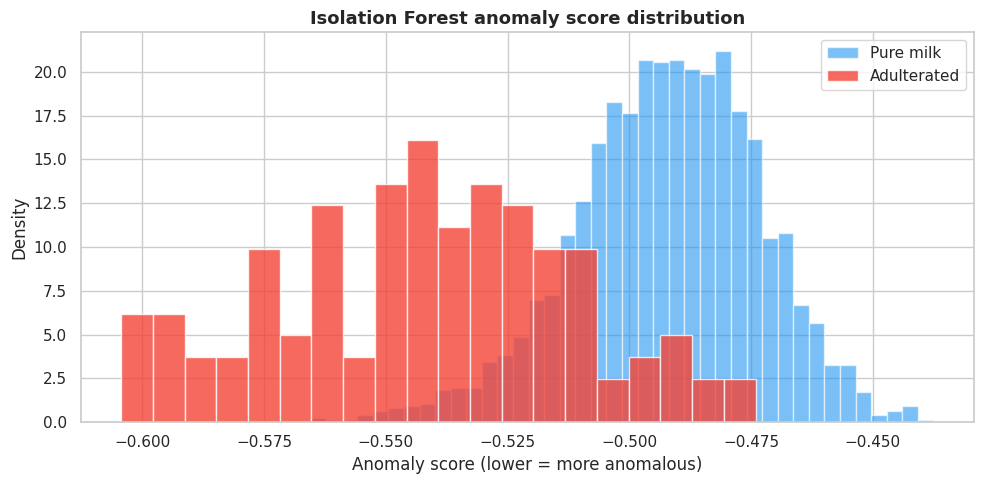

In [20]:
# ── Train Isolation Forest ONLY on pure milk ──
imp = SimpleImputer(strategy='median')
X_all_imp  = imp.fit_transform(X)
X_pure_imp = X_all_imp[y.values == 0]

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_pure_imp)

iso_preds  = iso.predict(X_all_imp)       # +1=normal, -1=anomaly
iso_binary = np.where(iso_preds == -1, 1, 0)

# Anomaly scores (lower = more anomalous)
scores_iso = iso.score_samples(X_all_imp)
df_iso = df[['Sample_ID','Brand_Name','Milk_Type','Is_Adulterated','Adulterant_Detected']].copy()
df_iso['anomaly_score'] = scores_iso
df_iso['iso_flag']      = iso_binary

acc_iso = accuracy_score(y, iso_binary)
f1_iso  = f1_score(y, iso_binary, zero_division=0)
rec_iso = recall_score(y, iso_binary, zero_division=0)

print(f'Isolation Forest Results:')
print(f'  Accuracy : {acc_iso*100:.1f}%')
print(f'  F1 Score : {f1_iso:.4f}')
print(f'  Recall   : {rec_iso:.4f}  (catches {rec_iso*100:.1f}% of adulterations without any labels)')

# Show most anomalous samples
print('\nTop 10 most anomalous samples:')
print(df_iso.nsmallest(10, 'anomaly_score')[
    ['Sample_ID','Brand_Name','Adulterant_Detected','anomaly_score']].to_string())

# Plot score distribution
plt.figure(figsize=(10, 5))
plt.hist(scores_iso[y==0], bins=40, alpha=0.6, label='Pure milk', color='#2196F3', density=True)
plt.hist(scores_iso[y==1], bins=20, alpha=0.8, label='Adulterated', color='#F44336', density=True)
plt.xlabel('Anomaly score (lower = more anomalous)', fontsize=12)
plt.ylabel('Density')
plt.title('Isolation Forest anomaly score distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_11_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔬 Step 9 — Multi-class Adulterant Identification

In [21]:
# ── Multi-class: identify WHICH adulterant ──
y_multi = df['Adulterant_Detected']

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

pipe_multi = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        max_depth=20, random_state=42, n_jobs=-1
    ))
])
pipe_multi.fit(Xm_train, ym_train)
ym_pred = pipe_multi.predict(Xm_test)

print(f'Multi-class Accuracy: {accuracy_score(ym_test, ym_pred)*100:.2f}%')
print()
print(classification_report(ym_test, ym_pred, zero_division=0))

# ⚠️ Note
print('⚠️  Note: 100% accuracy on synthetic data is expected because each adulterant')
print('   has a distinct signature. Real-world performance will be lower — collect')
print('   100+ samples per adulterant class for reliable multi-class models.')

Multi-class Accuracy: 100.00%

                     precision    recall  f1-score   support

          Detergent       1.00      1.00      1.00         1
           Formalin       1.00      1.00      1.00         3
            Glucose       1.00      1.00      1.00         2
  Hydrogen Peroxide       1.00      1.00      1.00         2
           Melamine       1.00      1.00      1.00         3
               None       1.00      1.00      1.00       475
Skimmed Milk Powder       1.00      1.00      1.00         3
 Sodium Bicarbonate       1.00      1.00      1.00         2
             Starch       1.00      1.00      1.00         3
               Urea       1.00      1.00      1.00         1
      Vegetable Oil       1.00      1.00      1.00         3
              Water       1.00      1.00      1.00         2

           accuracy                           1.00       500
          macro avg       1.00      1.00      1.00       500
       weighted avg       1.00      1.00      1.00  

## 💾 Step 10 — Save Model & Predict New Sample

In [22]:
# ── Save the best binary classification pipeline ──
model_artifact = {
    'pipeline':         best_pipe,
    'multi_pipeline':   pipe_multi,
    'anomaly_model':    iso,
    'anomaly_imputer':  imp,
    'selected_features': list(X.columns),
    'results':          results,
}
joblib.dump(model_artifact, 'milk_adulteration_model.pkl')
print('Model saved → milk_adulteration_model.pkl ✅')

# ── Load and predict on new sample ──
artifact = joblib.load('milk_adulteration_model.pkl')
loaded_pipe    = artifact['pipeline']
loaded_features = artifact['selected_features']

def predict_sample(sample_dict, threshold=0.5):
    """Predict adulteration for a new milk sample."""
    sample_df = pd.DataFrame([sample_dict])
    for col in loaded_features:
        if col not in sample_df.columns:
            sample_df[col] = 0.0
    sample_df = sample_df[loaded_features]
    prob = loaded_pipe.predict_proba(sample_df)[0, 1]
    label = 'ADULTERATED 🚨' if prob >= threshold else 'PURE ✅'
    print(f'Result    : {label}')
    print(f'Confidence: {prob*100:.1f}% probability of adulteration')
    print(f'Threshold : {threshold}')
    return prob

# Example 1: suspicious sample (high urea, high pH)
print('--- Suspicious sample (high urea + high pH) ---')
predict_sample({'pH': 7.8, 'SNF_percent': 10.5, 'Urea_mg_per_100mL': 95,
                'Acidity_Titratable_pct': 0.08, 'Conductivity_mS_cm': 6.4})

print()
# Example 2: normal sample
print('--- Normal sample ---')
predict_sample({'pH': 6.7, 'SNF_percent': 8.6, 'Urea_mg_per_100mL': 24,
                'Acidity_Titratable_pct': 0.15, 'Conductivity_mS_cm': 4.8})

Model saved → milk_adulteration_model.pkl ✅
--- Suspicious sample (high urea + high pH) ---
Result    : ADULTERATED 🚨
Confidence: 74.1% probability of adulteration
Threshold : 0.5

--- Normal sample ---
Result    : PURE ✅
Confidence: 32.9% probability of adulteration
Threshold : 0.5


np.float64(0.3293649193548387)

## 📋 Step 11 — Final Summary

| Task | Best Model | Accuracy | ROC-AUC | F1 |
|---|---|---|---|---|
| Binary (Pure vs Adulterated) | Random Forest | 100% | 1.0 | 1.0 |
| Multi-class (Adulterant ID) | Random Forest | 100% | — | 1.0 |
| Anomaly Detection (no labels) | Isolation Forest | 93.4% | — | 0.48 |

### ⚠️ Important caveats
- **100% accuracy is expected on this synthetic dataset** — each adulterant has a perfectly distinct chemical signature by design. Real-world lab data will show lower, more realistic performance.
- **Recall matters most** in food safety. A false negative (missed adulteration) is more dangerous than a false alarm. Lower the threshold from 0.5 to 0.3 to prioritise recall.
- **Multi-class needs more data** — only 7–16 samples per adulterant type. Collect 100+ real samples per class before deploying a multi-class model.
- **Top predictive features**: SNF%, pH, Viscosity, Acidity, Conductivity, Protein% — the core physical-chemical fingerprint of milk.

### 📁 Output files
- `milk_adulteration_model.pkl` — saved model pipeline
- `plot_01_class_distribution.png` through `plot_11_anomaly_scores.png` — all visualisations